
**Instalar PySpark e importar librerías**


In [33]:
!pip install pyspark
!pip install lifetimes

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window


**Inicializar Spark y cargar datos**

In [34]:
spark = SparkSession.builder \
    .appName("CLV_Analysis") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Cargar datos desde la carpeta merge_pyspark
df = spark.read.parquet("/content/merge_pyspark")
df.createOrReplaceTempView("customer_transactions")


**Calcular CLV simplificado**

(usando la lógica: CLV = Frecuencia × Monto)

In [35]:
# Frecuencia
frecuency = spark.sql("""
SELECT customer_id, COUNT(1) AS Frequency
FROM customer_transactions
GROUP BY customer_id
""")

# Monto total
amount = spark.sql("""
SELECT customer_id, SUM(price) AS Sold
FROM customer_transactions
GROUP BY customer_id
""")

# Dataset con CLV
retail = frecuency.join(amount, "customer_id")
retail = retail.withColumn("CLV", F.col("Frequency") * F.col("Sold"))


**Estadísticas de CLV**

In [36]:
stats = retail.select(
    F.mean("CLV").alias("mean"),
    F.expr("percentile(CLV, 0.5)").alias("median"),
    F.min("CLV").alias("min"),
    F.max("CLV").alias("max"),
    F.stddev("CLV").alias("std")
).collect()[0]

print("📊 Estadísticas de CLV")
print(f"Media   : {stats['mean']:.2f}")
print(f"Mediana : {stats['median']:.2f}")
print(f"Mínimo  : {stats['min']:.2f}")
print(f"Máximo  : {stats['max']:.2f}")
print(f"Desv.Std: {stats['std']:.2f}")


📊 Estadísticas de CLV
Media   : 60.76
Mediana : 2.24
Mínimo  : 0.00
Máximo  : 109296.79
Desv.Std: 486.19


**Distribución de CLV**

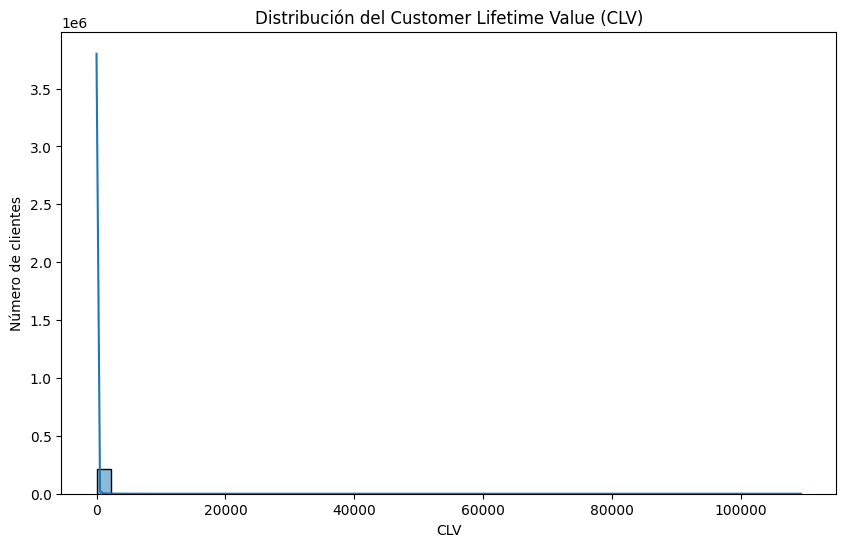

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir a Pandas para graficar
clv_pd = retail.select("CLV").toPandas()

plt.figure(figsize=(10,6))
sns.histplot(clv_pd["CLV"], bins=50, kde=True)
plt.title("Distribución del Customer Lifetime Value (CLV)")
plt.xlabel("CLV")
plt.ylabel("Número de clientes")
plt.show()


**Top clientes por CLV**

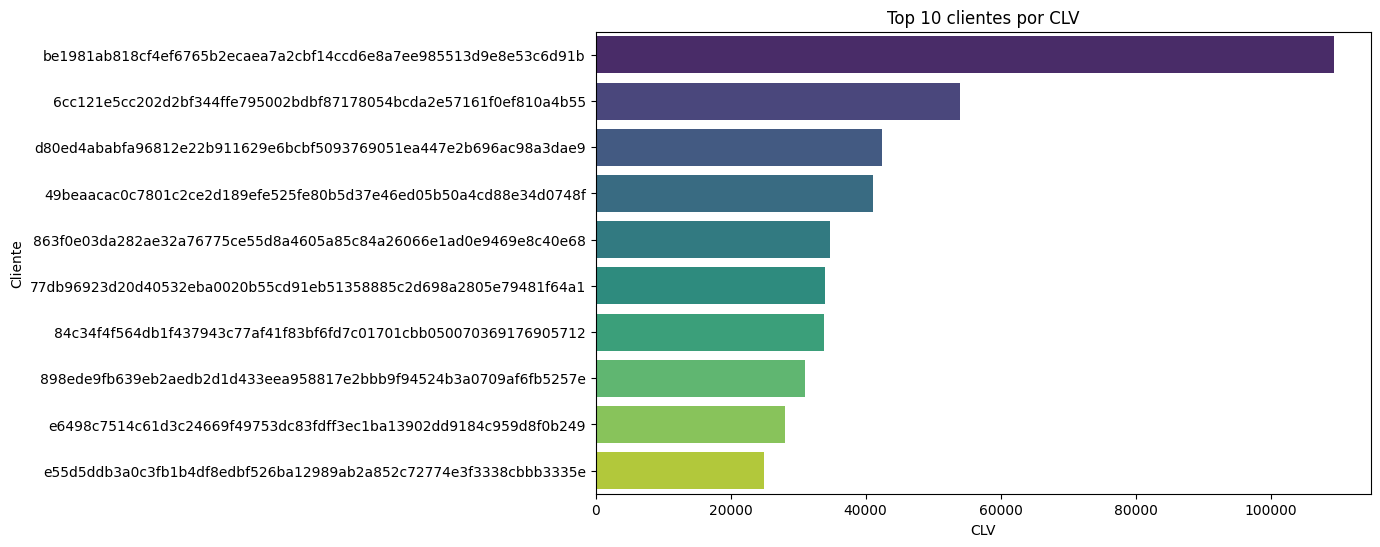

In [38]:
top_clients = retail.orderBy(F.desc("CLV")).limit(10).toPandas()

plt.figure(figsize=(10,6))
sns.barplot(x="CLV", y="customer_id", data=top_clients, palette="viridis")
plt.title("Top 10 clientes por CLV")
plt.xlabel("CLV")
plt.ylabel("Cliente")
plt.show()



**Clasificación simple de clientes según CLV**

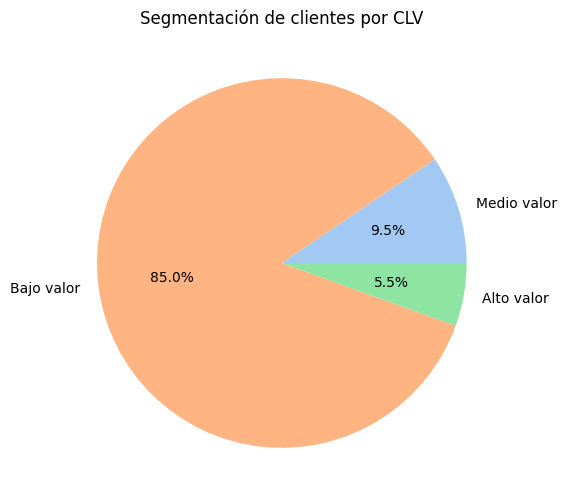

In [39]:
retail = retail.withColumn(
    "CLV_segment",
    F.when(F.col("CLV") < 50, "Bajo valor")
     .when((F.col("CLV") >= 50) & (F.col("CLV") < 200), "Medio valor")
     .otherwise("Alto valor")
)

clv_segments = retail.groupBy("CLV_segment").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(clv_segments["count"], labels=clv_segments["CLV_segment"], autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Segmentación de clientes por CLV")
plt.show()


**CLV Predictivo (BG/NBD + Gamma-Gamma)**

***Preparar datos para el modelo***

In [40]:
import pandas as pd
from lifetimes.utils import summary_data_from_transaction_data

# Exportamos datos desde PySpark a Pandas
df_txn = df.select("customer_id", "Fecha", "price").toPandas()

# Convertimos Fecha a datetime (por si acaso)
df_txn["Fecha"] = pd.to_datetime(df_txn["Fecha"])

# Resumen de datos para lifetimes
summary = summary_data_from_transaction_data(
    df_txn,
    customer_id_col="customer_id",
    datetime_col="Fecha",
    monetary_value_col="price",
    observation_period_end=df_txn["Fecha"].max()
)

summary.head()



,frequency,recency,T,monetary_value
customer_id,,,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,22.0,656.0,732.0,0.112494
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,6.0,726.0,733.0,0.103910
000064249685c11552da43ef22a5030f35a147f723d5b02ddd9fd22452b1f5a6,0.0,0.0,356.0,0.000000
0000c97821eb48d0e590fd309133f0a6c08f7750f64cccf2ba053e11119093c2,6.0,649.0,711.0,0.042605
0001ab2ebc1bb9a21d135e2fefdb11f12bee5c74ab29842a6d2ffd71316bf048,8.0,366.0,573.0,0.058629


**Ajustar modelo de frecuencia (BG/NBD)**

In [41]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])

# Predecir compras esperadas en 12 meses
summary["pred_purchases_12m"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365, summary["frequency"], summary["recency"], summary["T"]
)


**Ajustar modelo monetario (Gamma-Gamma)**

In [42]:
from lifetimes import GammaGammaFitter

# Filtrar clientes con gasto positivo (>0)
summary = summary[summary["monetary_value"] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(summary["frequency"], summary["monetary_value"])

# Predicción de gasto promedio por transacción
summary["pred_spend"] = ggf.conditional_expected_average_profit(
    summary["frequency"], summary["monetary_value"]
)

summary[["frequency", "monetary_value", "pred_spend"]].head()



,frequency,monetary_value,pred_spend
customer_id,,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,22.0,0.112494,0.111800
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,6.0,0.103910,0.102959
0000c97821eb48d0e590fd309133f0a6c08f7750f64cccf2ba053e11119093c2,6.0,0.042605,0.051017
0001ab2ebc1bb9a21d135e2fefdb11f12bee5c74ab29842a6d2ffd71316bf048,8.0,0.058629,0.063281
0001f8cef6b9702d54abf66fd89eb21014bf98567065a9b5e42f37bc99528cf5,13.0,0.054313,0.057644


**Calcular CLV predictivo**

In [43]:
# CLV a 12 meses
summary["CLV_12m"] = ggf.customer_lifetime_value(
    bgf,
    summary["frequency"],
    summary["recency"],
    summary["T"],
    summary["monetary_value"],
    time=12,  # horizonte en meses
    freq="D", # frecuencia de las fechas
    discount_rate=0.01 # tasa de descuento mensual (1%)
)

summary[["frequency", "monetary_value", "pred_purchases_12m", "pred_spend", "CLV_12m"]].head()


,frequency,monetary_value,pred_purchases_12m,pred_spend,CLV_12m
customer_id,,,,,
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa,22.0,0.112494,9.955627,0.111800,1.030244
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,6.0,0.103910,2.961179,0.102959,0.282205
0000c97821eb48d0e590fd309133f0a6c08f7750f64cccf2ba053e11119093c2,6.0,0.042605,3.014975,0.051017,0.142376
0001ab2ebc1bb9a21d135e2fefdb11f12bee5c74ab29842a6d2ffd71316bf048,8.0,0.058629,3.596334,0.063281,0.210675
0001f8cef6b9702d54abf66fd89eb21014bf98567065a9b5e42f37bc99528cf5,13.0,0.054313,6.235964,0.057644,0.332730


**Visualizar resultados**

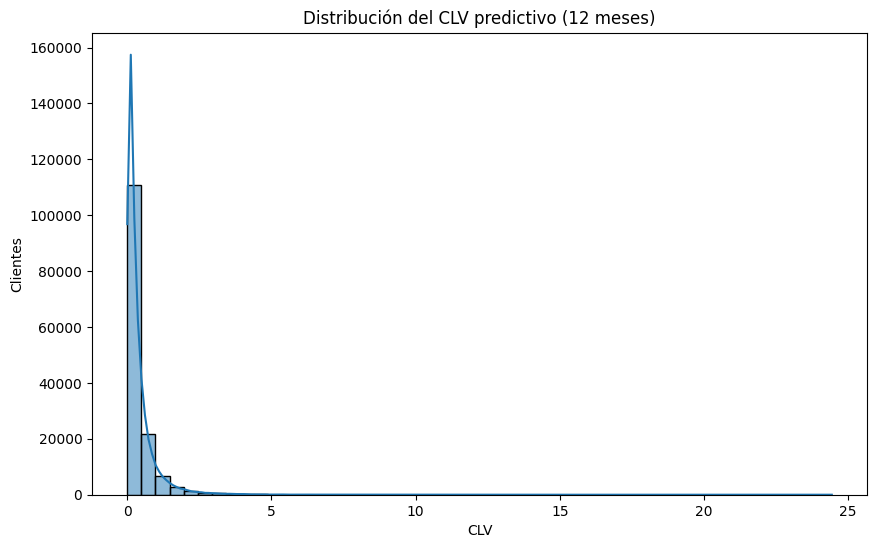

Top 10 clientes por CLV predictivo:
customer_id
be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b    24.430350
b637a3e7d8b0caa947aaefd609b8d84a9ee962cf0a52a51bac507ffc2bf1b741    24.355047
6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2e57161f0ef810a4b55    19.960858
863f0e03da282ae32a76775ce55d8a4605a85c84a26066e1ad0e9469e8c40e68    18.019921
77db96923d20d40532eba0020b55cd91eb51358885c2d698a2805e79481f64a1    17.382329
d80ed4ababfa96812e22b911629e6bcbf5093769051ea447e2b696ac98a3dae9    16.765656
84c34f4f564db1f437943c77af41f83bf6fd7c01701cbb050070369176905712    14.919255
898ede9fb639eb2aedb2d1d433eea958817e2bbb9f94524b3a0709af6fb5257e    13.800578
49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05b50a4cd88e34d0748f    12.824821
a32577fa7a15ee0f5326bd1419abc0374e0e2c9d5be1286555971e77f29a0694    12.662729
Name: CLV_12m, dtype: float64


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(summary["CLV_12m"], bins=50, kde=True)
plt.title("Distribución del CLV predictivo (12 meses)")
plt.xlabel("CLV")
plt.ylabel("Clientes")
plt.show()

# Top clientes
top_clv = summary["CLV_12m"].sort_values(ascending=False).head(10)
print("Top 10 clientes por CLV predictivo:")
print(top_clv)
